## **Курсовая работа 3-го курса ОП "Компьютерные науки и технологии" в НИУ ВШЭ-НН**
### **Название: Мониторинг репутации компаний через анализ упоминаний в сети**

**Срок выполнения:** с ..2026 г. по 21.05.2026 г.  
**Выполнил данную часть:** Иван Гайфиев (23КНТ-6)


### **Описание задания:**
Требуется разработать набор алгоритмов, задачей которых является NLP-анализ входных данных (упоминаний о компаниях) с целью формулировки основных тем, выявления наиболее часто упоминаемых слов и определения лучших и худших сторон компании на основе отзывов.

#### **Основные этапы:**
1) Подключение к базе данных Supabase и загрузка из неё набор упоминаний для последующего анализа в формате csv
2) Предобработать датафрейм, оставив данные, соответствующие определённым условиям
3) Разработать алгоритм по моделлированию ключевых тем
4) Разработать алгоритм по формированию облака слов
5) Разработать алгоритм по составлению списков позитивных и негативных аспектов
6) Выполнить анализ исходных данных с помощью этих алгоритмов и выгрузить результаты в БД 

#### **Полезные материалы:**
1) Доска MIRO с описанием системы и её компонентов - https://miro.com/app/board/uXjVHW0IYa8=/


### **Выполнение задания:**


#### **Этап 1: Подключение к БД и загрузка данных**
**Задание:**
Подключиться к базе данных Supabase и загрузить из неё набор упоминаний для последующего анализа в формате csv

**Выполнение:**  


In [1]:
import sys
!{sys.executable} -m pip install supabase google.colab scikit-learn nltk bertopic sentence-transformers natasha transformers torch sentencepiece gigachat -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 36.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 72.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 83.0 MB/s eta 0:00:00:00:0100:01


In [2]:
# import Topics_analysis as ta # importing file with functions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from supabase import create_client, Client
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from nltk.corpus import stopwords
import nltk
from bertopic import BERTopic
from natasha import MorphVocab, Doc, Segmenter, NewsEmbedding, NewsMorphTagger
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from collections import Counter
import time
from transformers import pipeline
from gigachat import GigaChat

In [7]:
company_id = 5

In [8]:
# Loading data
def mount_file():
    drive.mount('/content/drive')
    config_file = "/content/drive/MyDrive/Labs in Colab /Course work 3rd year/config.txt"
    return config_file

def get_config():
    config_file = mount_file()
    with open (config_file, 'r') as f:
        SUPABASE_URL = f.readline().strip()
        SUPABASE_KEY = f.readline().strip()
    supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)
    return supabase

def import_data(table_name, company_id, output_file="output.csv", size = 3000, batch_size=1000):
    supabase = get_config()
    all_data = []
    start = 0

    while len(all_data) < size:
        try:
            response = supabase.table(table_name).select("mention_id, text").eq("company_id", company_id).range(start, start + batch_size - 1).execute()

            data = response.data

            if not data:
                print(f"Нет данных для company_id={company_id}.")
                break
            
            all_data.extend(data)

            print(f"Сохранено {len(data)} строк (всего: {len(all_data)})")

            if len(data) < batch_size:
                break

            start += batch_size

        except Exception as e:
            print("Ошибка при получении данных:", e)
            print(e)

    if not all_data:
        print("Нет данных")
        return None

    df = pd.DataFrame(all_data)
    df.to_csv(output_file, index=False, encoding="utf-8-sig")
    print(f"Сохранено {len(df)} строк в {output_file}")

    return df
        
df = import_data("mentions", company_id, size = 4000)
print(df.head())



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Сохранено 1000 строк (всего: 1000)
Сохранено 1000 строк (всего: 2000)
Сохранено 1000 строк (всего: 3000)
Сохранено 1000 строк (всего: 4000)
Сохранено 4000 строк в output.csv
   mention_id                                               text
0        4959                             прекрасное приложение.
1        4616                          доставляет раньше посылки
2        4564  бесполезное приложение, не работает, просит вп...
3        4201                                         все холёщё
4        4202                                               good


In [ ]:
# Latent Dirichlet Allocation

def lda_topic_model(df, n_topics=3, n_words=5, max_iter=50):

    start_time = time.time()

    nltk.download("stopwords")
    russian_stopwords = stopwords.words("russian")
    texts = df["text"].dropna().astype(str).tolist()

    vectorizer = CountVectorizer(
        max_df=0.9,
        min_df=2,
        stop_words=russian_stopwords 
    )

    dtm = vectorizer.fit_transform(texts)
    feature_names = np.array(vectorizer.get_feature_names_out())

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        max_iter=max_iter,
        random_state=42
    )

    lda.fit(dtm)

    topics = []

    for topic_idx, topic in enumerate(lda.components_):
        top_indices = topic.argsort()[-n_words:][::-1]
        top_words = feature_names[top_indices].tolist()
        topics.append(top_words)

    doc_topic_dist = lda.transform(dtm)
    doc_topics = np.argmax(doc_topic_dist, axis=1)

    coherence_scores = [
        topic_coherence(topic, texts) for topic in topics
    ]

    avg_coherence = float(np.mean(coherence_scores))

    elapsed_time = time.time() - start_time

    result = {
        "model": "LDA",
        "topics": topics,
        "coherence": avg_coherence,
        "per_topic_coherence": coherence_scores,
        "time_sec": elapsed_time,
        "n_topics": n_topics
    }

    return result

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


{'model': 'LDA', 'topics': [['работает', 'приложение', 'это', 'вк', 'грузит', 'вообще'], ['приложение', 'вк', 'это', 'просто', 'почему', 'видео'], ['приложение', 'вк', 'хуже', 'это', 'очень', 'просто'], ['приложение', 'вк', 'реклама', 'работает', 'очень', 'всё'], ['приложение', 'это', 'вк', 'рекламы', 'пользоваться', 'kate']], 'coherence': 0.03947733333333307, 'per_topic_coherence': [0.04458666666666637, 0.04139333333333306, 0.04172666666666639, 0.03206666666666645, 0.03761333333333308], 'time_sec': 126.79404425621033, 'n_topics': 5}


In [ ]:
# Non-negative Matrix Factorization

def topic_coherence(words, texts):

        score = 0
        count = 0

        for doc in texts:
            doc = doc.lower()
            for i in range(len(words)):
                for j in range(i + 1, len(words)):
                    if words[i] in doc and words[j] in doc:
                        score += 1
                    count += 1

        return score / (count + 1e-9)

def nmf_topic_model(df, n_topics=3, n_words=5, max_iter=50):

    start_time = time.time()

    nltk.download("stopwords")
    russian_stopwords = stopwords.words("russian")
    texts = df["text"].dropna().astype(str).tolist()

    vectorizer = TfidfVectorizer(
        max_df=0.9,
        min_df=2,
        stop_words=russian_stopwords
    )

    dtm = vectorizer.fit_transform(texts)
    feature_names = np.array(vectorizer.get_feature_names_out())


    nmf = NMF(
        n_components=n_topics,
        max_iter=max_iter,
        random_state=42
    )

    nmf.fit(dtm)

    topics = []

    for topic_idx, topic in enumerate(nmf.components_):
        top_indices = topic.argsort()[-n_words:][::-1]
        top_words = feature_names[top_indices].tolist()
        topics.append(top_words)

    doc_topic_dist = nmf.transform(dtm)
    doc_topics = np.argmax(doc_topic_dist, axis=1)

    clusters = {i: [] for i in range(n_topics)}

    for text, topic_id in zip(texts, doc_topics):
        clusters[topic_id].append(text)

    coherence_scores = [
        topic_coherence(topic, texts) for topic in topics
    ]

    avg_coherence = float(np.mean(coherence_scores))

    elapsed_time = time.time() - start_time

    result = {
        "model": "NMF",
        "topics": topics,
        "clusters": clusters,
        "coherence": avg_coherence,
        "per_topic_coherence": coherence_scores,
        "time_sec": elapsed_time,
        "n_topics": n_topics
    }

    return result

nmf_topics = nmf_topic_model(df, n_topics = 5, n_words = 6)
nmf_topics

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


{'model': 'NMF',
 'topics': [['вк', 'грузит', 'видео', 'постоянно', 'вообще', 'это'],
  ['работает', 'впн', 'обновления', 'отвратительно', 'нормально', 'рада'],
  ['хуже', 'каждым', 'всё', 'обновлением', 'становится', 'днём'],
  ['kate', 'mobile', 'верните', 'доступ', 'api', 'это'],
  ['приложение', 'очень', 'хорошее', 'раньше', 'это', 'неудобное']],
 'clusters': {0: ['реал мешок барса чемпион',
   'во вконтакте захожу только ради музыки, кино и игр. и теперь проблема в том что в любой игре не возможно просмотреть рекламу, чтобы взять бонус от игры. жаль нельзя в отзыве скриншот поставить и показать, это баг со стороны вконтакте, а не игр. так как я во всех играх не могу просмотреть рекламу!!!!!!!',
   'не грузит ничего постоянно',
   'не могу войти в аккаунт, пишет что номер привязан уже, когда нажимаю кнопку войти, то перебрасывает обратно. (исправлю если подскажите)',
   'почему заблокированные сервисы работают сильно лучше чем отечественный ВК?',
   'Внезапно пропала возможность оп

In [31]:
def bertopic_model(df, n_words=5):

    start_time = time.time()

    texts = df["text"].dropna().astype(str).tolist()

    topic_model = BERTopic(
        language="multilingual",
        calculate_probabilities=True,
        verbose=False
    )

    topics, probs = topic_model.fit_transform(texts)

    unique_topics = set(topics)
    unique_topics.discard(-1)

    topic_words = []

    for topic_id in sorted(unique_topics):
        words = topic_model.get_topic(topic_id)

        top_words = [w for w, _ in words[:n_words]]
        topic_words.append(top_words)

    doc_topics = topics

    coherence_scores = [
        topic_coherence(topic, texts) for topic in topic_words
    ]

    avg_coherence = float(np.mean(coherence_scores)) if coherence_scores else 0

    elapsed_time = time.time() - start_time

    result = {
        "model": "BERTopic",
        "topics": topic_words,
        "doc_topic_assignment": doc_topics,
        "coherence": avg_coherence,
        "per_topic_coherence": coherence_scores,
        "time_sec": elapsed_time,
        "n_topics": len(topic_words)
    }

    return result

bert_topics = bertopic_model(df, 6)
bert_topics

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

{'model': 'BERTopic',
 'topics': [['перестал',
   'редми',
   'чистил',
   'настройка',
   'быструю',
   'переустанавливал'],
  ['домиком', 'моими', 'интересами', 'заходила', 'третьих', 'родственниками'],
  ['заходили', 'друзей', 'друзья', 'добавление', 'принял', 'действительное'],
  ['хлама', 'чуть', 'над', 'читаются', 'бесполезному', 'сотрудники'],
  ['трек', 'помойкой', 'передать', 'перегруженной', 'продать', 'следит'],
  ['vk', '12', 'выйдет', '2014', 'pdf', 'дополню'],
  ['самсунге', 'белый', 'банкротство', 'дохлая', 'вафли', 'величия'],
  ['держать', 'ресурсы', 'трафик', 'наоборот', 'качает', 'запойный'],
  ['приходят', 'видно', 'кажйды', 'уведомлениям', 'закрываешь', 'надоедает'],
  ['решать', 'фигню', 'хотите', 'писать', 'примерное', 'подам'],
  ['mobile', 'kate', 'офф', 'думают', 'самые', 'снёс'],
  ['советую',
   'заблокали',
   'интересует',
   'перегнать',
   'прописанные',
   'таковой'],
  ['whatsapp', 'войны', 'думать', 'ещë', 'вывод', 'умудрились'],
  ['днище', 'пускай',

In [9]:
# Summarization

giga = GigaChat(
    credentials="MDE5ZTQ2MDAtMzk1MC03MTAwLWJlOGQtZTgyYmNmOTk5MGYwOjMwZDlhY2MwLTllNGItNDZmNy1hY2QwLTE2MjYxYzVlODY5Yw==",
    verify_ssl_certs=False
)

def gigachat_summarize_topic(words):

    if not words:
        return "Неопределённая тема"

    prompt = (
        "Сформулируй короткое осмысленное предложение на русском языке.\n"
        "Это название темы пользовательских отзывов.\n"
        "Максимум 12-15 слов.\n"
        "Сформулируй исключительно предложение без добавления в начале 'отзывы'.\n\n"
        f"Ключевые слова: {', '.join(words)}"
    )

    response = giga.chat(
        {
            "messages": [
                {
                    "role": "system",
                    "content": "Ты превращаешь ключевые слова в понятные темы."
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            "temperature": 0.3,
            "max_tokens": 60
        }
    )

    return response.choices[0].message.content.strip()

import pandas as pd

def build_topics_dataframe(nmf_result, method="NMF + GigaChat"):
    rows = []

    for i, topic_words in enumerate(nmf_result["topics"]):

        sentence = gigachat_summarize_topic(topic_words)

        relevance = nmf_result.get(
            "per_topic_coherence",
            [0.8] * len(nmf_result["topics"])
        )[i]

        rows.append({
            "sentence": sentence.strip('"'),
            "method": method,
            "relevance": float(relevance)
        })

    return pd.DataFrame(rows)

nmf_result = nmf_topic_model(df, n_topics = 6, n_words = 5)
nmf_result
df_nmf_summ = build_topics_dataframe(nmf_result, method="NMF + GigaChat")
df_nmf_summ


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,sentence,method,relevance
0,"Отзывы: Отлично, удобно, большое спасибо!",NMF + GigaChat,0.002475
1,"Супер компания, просто всеми советуют!",NMF + GigaChat,0.000600
2,"Приложение очень удобное, быстрое и хорошее.",NMF + GigaChat,0.017125
3,"Отзывы: всё устраивает, нормально работает и л...",NMF + GigaChat,0.002725
4,"Отзывы: быстро, нравится, очень хорошо, нормал...",NMF + GigaChat,0.004050
5,"Огромное спасибо, всем очень понравилось, клас...",NMF + GigaChat,0.003250


In [21]:
# Saving results to DB
def upload_to_db(final_topics, company_id):

    df = final_topics.copy()

    df = df.rename(columns={
        "sentence": "trend_text",
        "method": "source"
    })

    df["company_id"] = company_id
    df["trend_type"] = "general"

    if "relevance" not in df.columns:
        df["relevance"] = 0.8

    supabase = get_config()
    supabase.table("topic_summary").delete().eq("company_id", company_id).execute()
    records = df.to_dict(orient="records")

    for r in records:
        data = {
            "company_id": int(r["company_id"]),
            "trend_text": r.get("trend_text", ""),
            "trend_type": r.get("trend_type", "general"),
            "source": r.get("source", "unknown"),
            "relevance": float(r.get("relevance", 0.8))
        }

        try:
            supabase.table("topic_summary").insert(data).execute()

            print("Inserted:", data["trend_text"][:60])

        except Exception as e:
            print("Error:", e, data)

upload_to_db(df_nmf_summ, company_id)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Inserted: Приложение «ВК» раньше не грузило так сильно.
Inserted: Опыт использования VPN: работает нормально/глючит/отвратител
Inserted: С каждым днем и обновлением становится всё хуже.
Inserted: Kate просит вернуть доступ к мобильному API.


In [22]:
def get_word_frequencies(df, top_n=50):
    segmenter = Segmenter()
    morph_vocab = MorphVocab()
    emb = NewsEmbedding()
    morph_tagger = NewsMorphTagger(emb)

    text = " ".join(df["text"].dropna().astype(str).tolist())
    
    doc = Doc(text)
    doc.segment(segmenter)
    doc.tag_morph(morph_tagger)
    
    allowed_pos = {'NOUN', 'ADJ', 'VERB'}
    
    important_words = []

    for token in doc.tokens:
        if token.pos in allowed_pos:
            token.lemmatize(morph_vocab)
            lemma = token.lemma.lower()
            
            if lemma.isalpha() and len(lemma) > 2:
                important_words.append(lemma)

    word_counts = Counter(important_words)
    most_common = dict(word_counts.most_common(top_n))

    return most_common

cloud_words_dict = get_word_frequencies(df, 30)
cloud_words_dict

{'приложение': 7267,
 'работать': 3050,
 'реклама': 3020,
 'сообщение': 2082,
 'мочь': 1876,
 'лента': 1392,
 'обновление': 1378,
 'музыка': 1363,
 'стать': 1344,
 'видео': 1336,
 'пользоваться': 1332,
 'сделать': 1278,
 'нет': 1273,
 'человек': 1146,
 'канал': 1123,
 'хуже': 1075,
 'пост': 1071,
 'раз': 1069,
 'чат': 1064,
 'нужный': 1024,
 'грузить': 983,
 'вернуть': 948,
 'год': 936,
 'хороший': 917,
 'быть': 889,
 'проблема': 817,
 'другой': 771,
 'аккаунт': 765,
 'новый': 765,
 'невозможный': 758}

In [23]:
def upload_wordcloud_to_db(word_freq_dict, company_id):

    supabase = get_config()
    records =[
        {
            "company_id": int(company_id),
            "word": str(word),
            "frequency": int(freq)
        }
        for word, freq in word_freq_dict.items()
    ]
    
    try:
        supabase.table("wordcloud_cache").delete().eq("company_id", company_id).execute()
        response = supabase.table("wordcloud_cache").insert(records).execute()
        print(f"Успешно загружено {len(records)} слов для компании {company_id}")
        
    except Exception as e:
        print(f"Ошибка при загрузке облака слов в БД: {e}")
        return None

upload_wordcloud_to_db(cloud_words_dict, company_id)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Успешно загружено 30 слов для компании 1


In [95]:
# Comparing 3 algorithms

def run_experiment(df, topic_range=[2, 3, 5, 7, 10]):
    
    results = []

    for n_topics in topic_range:
        print(f"Running for n_topics = {n_topics}")

        lda_res = lda_topic_model(df, n_topics=n_topics, n_words=5)

        results.append({
            "model": "LDA",
            "n_topics": n_topics,
            "coherence": lda_res["coherence"],
            "time": lda_res["time_sec"]
        })

        nmf_res = nmf_topic_model(df, n_topics=n_topics, n_words=5)

        results.append({
            "model": "NMF",
            "n_topics": n_topics,
            "coherence": nmf_res["coherence"],
            "time": nmf_res["time_sec"]
        })

        bert_res = bertopic_model(df)

        results.append({
            "model": "BERTopic",
            "n_topics": bert_res["n_topics"],
            "coherence": bert_res["coherence"],
            "time": bert_res["time_sec"]
        })

    return pd.DataFrame(results)

In [98]:
def plot_results(results_df):

    # Coherence plot
    plt.figure(figsize=(10, 5))

    for model in results_df["model"].unique():
        subset = results_df[results_df["model"] == model]
        plt.plot(subset["n_topics"], subset["coherence"], marker="o", label=model)

    plt.title("Coherence vs Number of Topics")
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence")
    plt.legend()
    plt.grid()
    plt.show()

    # Time plot
    plt.figure(figsize=(10, 5))

    for model in results_df["model"].unique():
        subset = results_df[results_df["model"] == model]
        plt.plot(subset["n_topics"], subset["time"], marker="o", label=model)

    plt.title("Execution Time vs Number of Topics")
    plt.xlabel("Number of Topics")
    plt.ylabel("Time (seconds)")
    plt.legend()
    plt.grid()
    plt.show()

Running for n_topics = 2


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running for n_topics = 3


...

Running for n_topics = 10


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


       model  n_topics  coherence        time
0        LDA         2   0.049130   78.113898
1        NMF         2   0.027390    0.346079
2   BERTopic       220   0.003956  260.689391
3        LDA         3   0.043627   79.010252
4        NMF         3   0.022887    0.378067
5   BERTopic       219   0.004357  263.827062
6        LDA         5   0.041308   62.061024
7        NMF         5   0.014504    0.482932
8   BERTopic       205   0.004173  253.607999
9        LDA         7   0.035329   58.058455
10       NMF         7   0.013154    0.614736
11  BERTopic       215   0.003135  253.967602
12       LDA        10   0.036610   54.674459
13       NMF        10   0.010136    0.791332
14  BERTopic       203   0.005555  253.694116


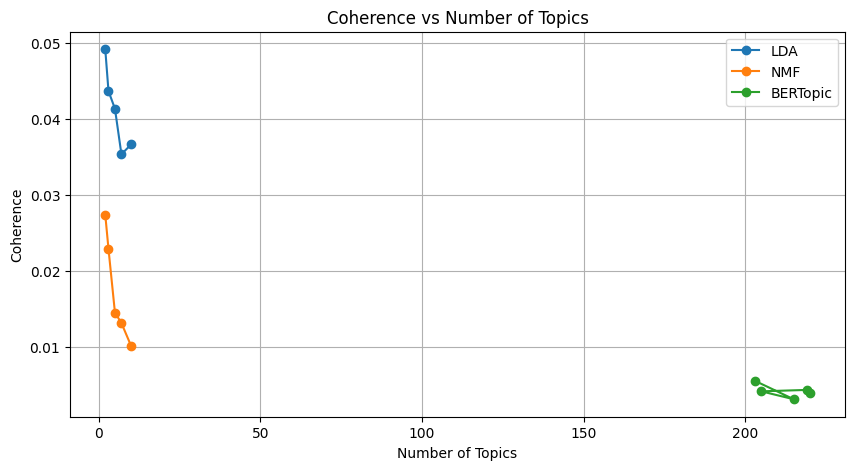

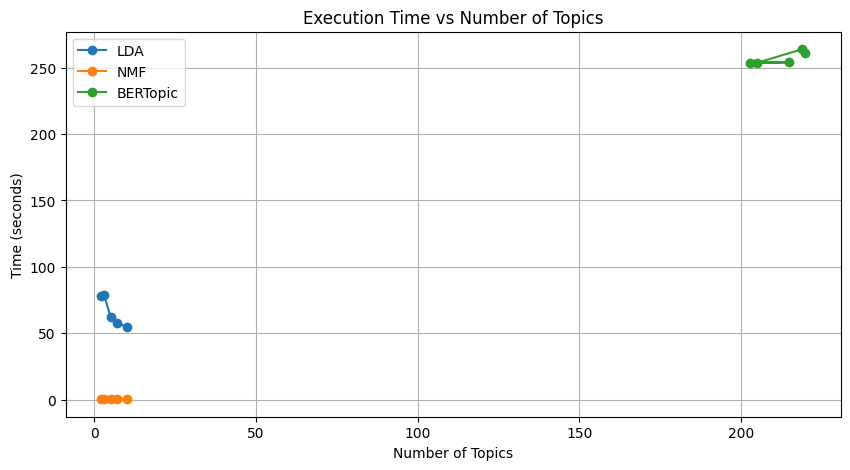

In [97]:
results_df = run_experiment(df)
print(results_df)

plot_results(results_df)